# PBX 60 hpf Stripped Logistic Tests

Only two tests are run:

1. `crispr-pbx4` vs `crispr-pbx1+4`
2. `crispr-pbx1` vs `crispr-inj-ctrl`

Each test uses one embryo-level vector: the mean `z_mu_b*` embedding over the 5-hour window centered at 60 hpf.


In [1]:
from pathlib import Path
import sys

import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score
from sklearn.model_selection import StratifiedKFold, cross_val_predict

REPO_ROOT = Path('/Users/nick/Projects/repositories/morphseq')
SRC_DIR = REPO_ROOT / 'src'
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

from analyze.utils.data_loading import load_experiments

BUILD_DIR = Path('/Users/nick/Projects/data/morphseq/build06_output')
FIG_DIR = Path('/Users/nick/Library/CloudStorage/GoogleDrive-nlammers@uw.edu/My Drive/projects/K99/Materials/figure components/Aim 2')
FIG_DIR.mkdir(parents=True, exist_ok=True)

EXPERIMENT_IDS = ['20251207_pbx']
TIME_CENTER_HPF = 60.0
TIME_WINDOW_HOURS = 5.0
WINDOW_START_HPF = TIME_CENTER_HPF - TIME_WINDOW_HOURS / 2
WINDOW_END_HPF = TIME_CENTER_HPF + TIME_WINDOW_HOURS / 2
FEATURE_PREFIX = 'z_mu_b'
N_PERMUTATIONS = 1000  # same order as original notebook calls
N_SPLITS = 5
RANDOM_STATE = 42
WITHIN_WINDOW_TIME_STRATA_WIDTH = 0.5
BOXPLOT_Y_MIN = -0.75
BOXPLOT_Y_MAX = 1.55

mpl.rcParams.update({
    'figure.dpi': 150,
    'savefig.dpi': 300,
    'font.family': 'Arial',
    'font.sans-serif': ['Arial'],
    'font.size': 11,
    'axes.labelsize': 12,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'pdf.fonttype': 42,
    'ps.fonttype': 42,
    'axes.edgecolor': 'black',
    'axes.labelcolor': 'black',
    'xtick.color': 'black',
    'ytick.color': 'black',
    'text.color': 'black',
    'axes.grid': False,
    'savefig.bbox': 'tight',
    'savefig.facecolor': 'white',
})

df = load_experiments(EXPERIMENT_IDS, build_dir=BUILD_DIR, verbose=True)

# The requested build_dir currently has predicted_stage_hpf entirely empty for this experiment.
# Use real acquisition age instead: start age + elapsed imaging time.
df['stage_hpf'] = pd.to_numeric(df['predicted_stage_hpf'], errors='coerce')
if df['stage_hpf'].notna().sum() == 0:
    df['stage_hpf'] = (
        pd.to_numeric(df['start_age_hpf'], errors='coerce')
        + pd.to_numeric(df['relative_time_s'], errors='coerce') / 3600
    )

print(f'Window: {WINDOW_START_HPF:.1f}-{WINDOW_END_HPF:.1f} hpf')
print('Embryos in window:')
window_mask = df['stage_hpf'].between(WINDOW_START_HPF, WINDOW_END_HPF, inclusive='both')
print(df.loc[window_mask].groupby('genotype')['embryo_id'].nunique())




Loaded 20251207_pbx: 8191 rows
  Genotypes: {'crispr-pbx1+4': 2871, 'crispr-pbx4': 2777, 'crispr-pbx1': 2035, 'crispr-inj-ctrl': 508}

Total: 8191 rows from 1 experiments
Overall genotype distribution:
crispr-pbx1+4      2871
crispr-pbx4        2777
crispr-pbx1        2035
crispr-inj-ctrl     508
Name: genotype, dtype: int64
Window: 57.5-62.5 hpf
Embryos in window:
genotype
crispr-inj-ctrl     8
crispr-pbx1        23
crispr-pbx1+4      31
crispr-pbx4        28
Name: embryo_id, dtype: int64


In [2]:
def get_feature_cols(df, prefix=FEATURE_PREFIX):
    cols = [c for c in df.columns if c.startswith(prefix)]
    if not cols:
        raise ValueError(f'No columns found with prefix {prefix!r}')
    return cols


def make_window_table(df, positive_label, negative_label):
    feature_cols = get_feature_cols(df)
    use_cols = ['embryo_id', 'genotype', 'stage_hpf', *feature_cols]
    sub = df.loc[
        df['genotype'].isin([positive_label, negative_label])
        & df['stage_hpf'].between(WINDOW_START_HPF, WINDOW_END_HPF, inclusive='both'),
        use_cols,
    ].copy()
    if sub.empty:
        raise ValueError(f'No rows for {positive_label} vs {negative_label} in requested window')

    embryo_table = (
        sub.groupby(['embryo_id', 'genotype'], as_index=False)
        .agg({**{c: 'mean' for c in feature_cols}, 'stage_hpf': 'mean'})
        .dropna(subset=feature_cols)
    )
    if embryo_table['genotype'].nunique() != 2:
        raise ValueError(f'Need both groups for {positive_label} vs {negative_label}')
    return embryo_table, feature_cols


def permute_within_time_strata(y, strata, rng):
    y_perm = y.copy()
    for stratum in np.unique(strata):
        mask = strata == stratum
        if mask.sum() > 1:
            y_perm[mask] = rng.permutation(y_perm[mask])
    return y_perm


def run_binary_logistic_test(df, positive_label, negative_label, stem):
    embryo_table, feature_cols = make_window_table(df, positive_label, negative_label)
    X = embryo_table[feature_cols].to_numpy(dtype=float)
    y = (embryo_table['genotype'].to_numpy() == positive_label).astype(int)

    counts = pd.Series(y).value_counts().reindex([0, 1], fill_value=0)
    min_count = int(counts.min())
    if min_count < 3:
        raise ValueError(f'Too few embryos in one class for {positive_label} vs {negative_label}: {counts.to_dict()}')

    n_splits_actual = min(N_SPLITS, min_count)
    clf = LogisticRegression(max_iter=1000, solver='liblinear', class_weight='balanced', random_state=RANDOM_STATE)
    cv = StratifiedKFold(n_splits=n_splits_actual, shuffle=True, random_state=RANDOM_STATE)

    probs = cross_val_predict(clf, X, y, cv=cv, method='predict_proba')[:, 1]
    auroc_obs = float(roc_auc_score(y, probs))

    strata = np.floor((embryo_table['stage_hpf'].to_numpy() - WINDOW_START_HPF) / WITHIN_WINDOW_TIME_STRATA_WIDTH).astype(int)
    rng = np.random.default_rng(RANDOM_STATE)
    null_aurocs = []
    for _ in range(N_PERMUTATIONS):
        y_perm = permute_within_time_strata(y, strata, rng)
        if len(np.unique(y_perm)) < 2:
            continue
        try:
            probs_perm = cross_val_predict(clf, X, y_perm, cv=cv, method='predict_proba')[:, 1]
            null_aurocs.append(float(roc_auc_score(y_perm, probs_perm)))
        except Exception:
            continue
    null_aurocs = np.asarray(null_aurocs, dtype=float)
    if null_aurocs.size == 0:
        raise RuntimeError(f'No valid null AUROCs for {positive_label} vs {negative_label}')

    pval = float((np.sum(null_aurocs >= auroc_obs) + 1) / (null_aurocs.size + 1))

    full_clf = LogisticRegression(max_iter=1000, solver='liblinear', class_weight='balanced', random_state=RANDOM_STATE)
    full_clf.fit(X, y)
    coef = full_clf.coef_.ravel()
    coef_norm = float(np.linalg.norm(coef))
    if coef_norm == 0:
        raise RuntimeError(f'Zero coefficient vector for {positive_label} vs {negative_label}')

    embryo_table = embryo_table.copy()
    embryo_table['positive_class'] = positive_label
    embryo_table['negative_class'] = negative_label
    embryo_table['comparison'] = f'{positive_label} vs {negative_label}'
    score_sign = -1.0 if stem == 'pbx4_vs_pbx14_60hpf' else 1.0
    embryo_table['decision_score_raw'] = full_clf.decision_function(X) / coef_norm
    embryo_table['decision_score'] = score_sign * embryo_table['decision_score_raw']
    embryo_table['score_sign_for_plot'] = score_sign
    embryo_table['score_direction'] = f'>0 favors {positive_label}' if score_sign > 0 else f'>0 favors {negative_label}'
    embryo_table['cv_pred_proba_positive'] = probs

    if stem == 'pbx4_vs_pbx14_60hpf':
        boxplot_left_label = positive_label
    elif stem == 'pbx1_vs_ctrl_60hpf':
        boxplot_left_label = negative_label
    else:
        boxplot_left_label = negative_label
    boxplot_center_shift = float(
        embryo_table.loc[embryo_table['genotype'] == boxplot_left_label, 'decision_score'].median()
    )
    embryo_table['boxplot_left_label'] = boxplot_left_label
    embryo_table['boxplot_center_shift'] = boxplot_center_shift
    embryo_table['decision_score_boxplot_centered'] = embryo_table['decision_score'] - boxplot_center_shift

    summary = {
        'comparison': f'{positive_label} vs {negative_label}',
        'positive_class': positive_label,
        'negative_class': negative_label,
        'window_start_hpf': WINDOW_START_HPF,
        'window_end_hpf': WINDOW_END_HPF,
        'n_positive_embryos': int((y == 1).sum()),
        'n_negative_embryos': int((y == 0).sum()),
        'n_features': len(feature_cols),
        'n_splits': int(n_splits_actual),
        'n_permutations': int(null_aurocs.size),
        'auroc_obs': auroc_obs,
        'auroc_null_mean': float(null_aurocs.mean()),
        'auroc_null_std': float(null_aurocs.std()),
        'pval': pval,
        'score_direction': f'>0 favors {positive_label}' if stem != 'pbx4_vs_pbx14_60hpf' else f'>0 favors {negative_label}',
        'score_sign_for_plot': -1.0 if stem == 'pbx4_vs_pbx14_60hpf' else 1.0,
        'boxplot_left_label': boxplot_left_label,
        'boxplot_center_shift': boxplot_center_shift,
    }

    plot_score_boxplot(embryo_table, positive_label, negative_label, summary, stem)
    return summary, embryo_table


def plot_score_boxplot(score_df, positive_label, negative_label, summary, stem):
    if stem == 'pbx4_vs_pbx14_60hpf':
        order = [positive_label, negative_label]
        colors = ['#F8A783', '#D96A45']
    elif stem == 'pbx1_vs_ctrl_60hpf':
        order = [negative_label, positive_label]
        colors = ['#A8A8A8', '#5294D0']
    else:
        order = [negative_label, positive_label]
        colors = ['#A8A8A8', '#5294D0']
    data = [score_df.loc[score_df['genotype'] == label, 'decision_score_boxplot_centered'].to_numpy() for label in order]

    fig, ax = plt.subplots(figsize=(1.25, 3.5))
    bp = ax.boxplot(
        data,
        positions=np.arange(len(order)),
        widths=0.55,
        patch_artist=True,
        showfliers=False,
        medianprops={'color': 'black', 'linewidth': 1.5},
        boxprops={'edgecolor': 'black', 'linewidth': 1.2},
        whiskerprops={'color': 'black', 'linewidth': 1.2},
        capprops={'color': 'black', 'linewidth': 1.2},
    )
    for patch, color in zip(bp['boxes'], colors):
        patch.set_facecolor(color)
        patch.set_alpha(0.75)

    ax.set_ylim(BOXPLOT_Y_MIN, BOXPLOT_Y_MAX)

    ax.axhline(0, color='black', linewidth=1.0, linestyle=(0, (3, 2)), alpha=0.65)
    ax.set_xticks(np.arange(len(order)))
    ax.set_xticklabels(order, rotation=25, ha='right')
    ax.set_ylabel('Signed distance from decision plane')
    ax.set_title(f"AUROC={summary['auroc_obs']:.2f}, p={summary['pval']:.3f}")
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['bottom'].set_linewidth(1.2)
    ax.spines['left'].set_linewidth(1.2)
    ax.tick_params(axis='both', colors='black', width=1.1)

    for suffix in ['png', 'pdf']:
        fig.savefig(FIG_DIR / f'{stem}_distance_score_boxplot.{suffix}')
    plt.show()







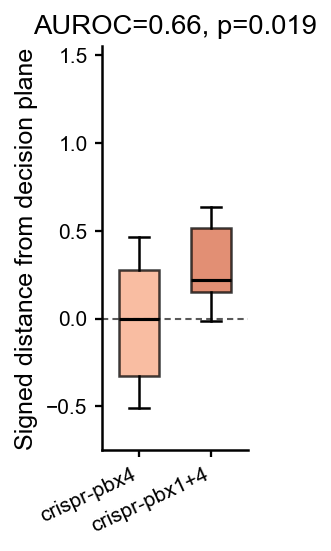

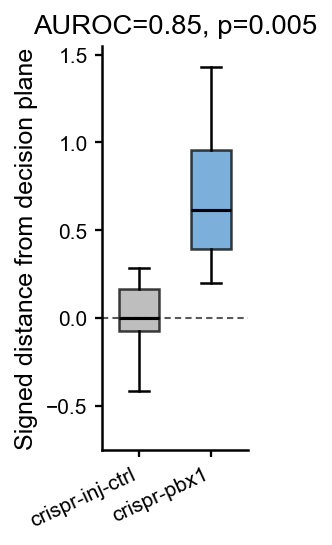

,comparison,positive_class,negative_class,window_start_hpf,window_end_hpf,n_positive_embryos,n_negative_embryos,n_features,n_splits,n_permutations,auroc_obs,auroc_null_mean,auroc_null_std,pval,score_direction,score_sign_for_plot,boxplot_left_label,boxplot_center_shift
0,crispr-pbx4 vs crispr-pbx1+4,crispr-pbx4,crispr-pbx1+4,57.5,62.5,28,31,80,5,1000,0.663594,0.472965,0.099467,0.018981,>0 favors crispr-pbx1+4,-1.0,crispr-pbx4,-0.163181
1,crispr-pbx1 vs crispr-inj-ctrl,crispr-pbx1,crispr-inj-ctrl,57.5,62.5,23,8,80,5,1000,0.847826,0.449005,0.174180,0.004995,>0 favors crispr-pbx1,1.0,crispr-inj-ctrl,-0.451412


In [3]:
comparisons = [
    ('crispr-pbx4', 'crispr-pbx1+4', 'pbx4_vs_pbx14_60hpf'),
    ('crispr-pbx1', 'crispr-inj-ctrl', 'pbx1_vs_ctrl_60hpf'),
]

summary_rows = []
score_tables = []
for positive_label, negative_label, stem in comparisons:
    summary, scores = run_binary_logistic_test(df, positive_label, negative_label, stem)
    summary_rows.append(summary)
    score_tables.append(scores[['embryo_id', 'genotype', 'stage_hpf', 'comparison', 'positive_class', 'negative_class', 'decision_score_raw', 'decision_score', 'decision_score_boxplot_centered', 'score_sign_for_plot', 'score_direction', 'boxplot_left_label', 'boxplot_center_shift', 'cv_pred_proba_positive']])

summary_df = pd.DataFrame(summary_rows)
scores_df = pd.concat(score_tables, ignore_index=True)

summary_df.to_csv(FIG_DIR / 'pbx_60hpf_logistic_test_summary.csv', index=False)
scores_df.to_csv(FIG_DIR / 'pbx_60hpf_logistic_distance_scores.csv', index=False)

summary_df




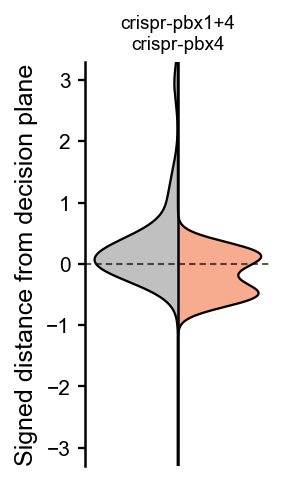

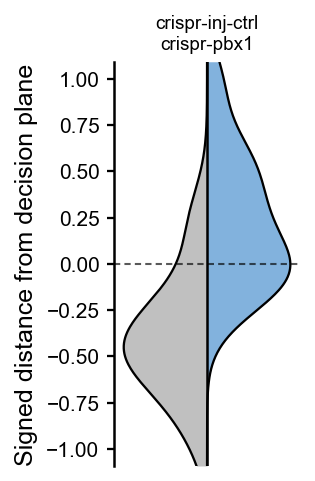

In [4]:
# Split kernel density versions
from scipy.stats import gaussian_kde


def _kde_on_grid(values, y_grid):
    values = np.asarray(values, dtype=float)
    values = values[np.isfinite(values)]
    if values.size < 2 or np.unique(np.round(values, 10)).size < 2:
        center = float(values[0]) if values.size else 0.0
        sd = 0.08 if values.size < 2 else max(float(np.std(values)), 0.08)
        density = np.exp(-0.5 * ((y_grid - center) / sd) ** 2)
    else:
        density = gaussian_kde(values)(y_grid)
    if np.nanmax(density) > 0:
        density = density / np.nanmax(density)
    return density


def plot_split_density(score_df, positive_label, negative_label, stem):
    order = [negative_label, positive_label]
    colors = ['#A8A8A8', '#F68D64'] if stem == 'pbx4_vs_pbx14_60hpf' else ['#A8A8A8', '#5294D0']
    data = [score_df.loc[score_df['genotype'] == label, 'decision_score'].to_numpy() for label in order]

    max_abs = max(np.nanmax(np.abs(values)) for values in data if len(values) > 0)
    y_lim = max_abs * 1.12 if np.isfinite(max_abs) and max_abs > 0 else 1.0
    y_grid = np.linspace(-y_lim, y_lim, 300)
    left_density = 0.43 * _kde_on_grid(data[0], y_grid)
    right_density = 0.43 * _kde_on_grid(data[1], y_grid)

    fig, ax = plt.subplots(figsize=(1.6, 3.5))
    ax.fill_betweenx(y_grid, -left_density, 0, color=colors[0], alpha=0.72, linewidth=0)
    ax.plot(-left_density, y_grid, color='black', linewidth=1.1)
    ax.fill_betweenx(y_grid, 0, right_density, color=colors[1], alpha=0.72, linewidth=0)
    ax.plot(right_density, y_grid, color='black', linewidth=1.1)

    ax.axvline(0, color='black', linewidth=1.2)
    ax.axhline(0, color='black', linewidth=1.0, linestyle=(0, (3, 2)), alpha=0.65)
    ax.set_ylim(-y_lim, y_lim)
    ax.set_xlim(-0.48, 0.48)
    ax.set_xticks([])
    ax.set_ylabel('Signed distance from decision plane')
    ax.set_title(f'{negative_label}\n{positive_label}', fontsize=9)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['bottom'].set_visible(False)
    ax.spines['left'].set_linewidth(1.2)
    ax.tick_params(axis='y', colors='black', width=1.1)

    for suffix in ['png', 'pdf']:
        fig.savefig(FIG_DIR / f'{stem}_distance_score_split_kde.{suffix}')
    plt.show()


for positive_label, negative_label, stem in comparisons:
    comp = f'{positive_label} vs {negative_label}'
    plot_split_density(scores_df.loc[scores_df['comparison'] == comp], positive_label, negative_label, stem)

